In [3]:
# 强制 Jupyter 每次运行都重新加载所有被修改过的外部 .py 文件
%load_ext autoreload
%autoreload 2

In [4]:
print("EcoGrid-Quant 引擎启动成功！准备摄入能源数据。")


EcoGrid-Quant 引擎启动成功！准备摄入能源数据。


In [5]:
# 1. 召唤刚才安装的 Pandas，并给它起个简写叫 'pd'
import pandas as pd

# 2. 模拟过去 5 天，某个微型绿色电网的每日发电数据
# (这里用的是 Python 的字典格式，就像一本小名册)
raw_data = {
    "日期": ["2026-05-01", "2026-05-02", "2026-05-03", "2026-05-04", "2026-05-05"],
    "风电出力_MW": [12.5, 14.2, 8.9, 22.1, 19.5],  # 兆瓦 (MW)
    "光伏出力_MW": [45.2, 42.1, 15.6, 50.3, 48.9],
    "电网碳排放因子_gCO2/kWh": [320, 310, 580, 210, 230] # 阴天光伏少时，可能要烧煤，碳排就高
}

# 3. 将这本小名册，塞进 Pandas 的 DataFrame (超级表格) 引擎里
df_grid = pd.DataFrame(raw_data)

# 4. 把这个超级表格打印出来，看看它长什么样
df_grid

,日期,风电出力_MW,光伏出力_MW,电网碳排放因子_gCO2/kWh
0,2026-05-01,12.5,45.2,320
1,2026-05-02,14.2,42.1,310
2,2026-05-03,8.9,15.6,580
3,2026-05-04,22.1,50.3,210
4,2026-05-05,19.5,48.9,230


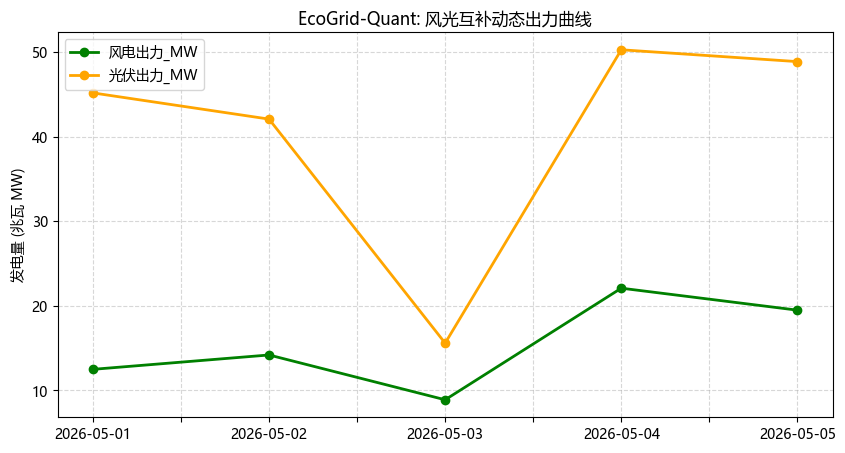

In [6]:
# 1. 召唤画图神器 Matplotlib 的核心模块，并简写为 'plt'
import matplotlib.pyplot as plt

# 2. 【强迫症专属防雷系统】强制开启中文支持，防止表头变成丑陋的方块
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei'] # 优先使用微软雅黑或黑体
plt.rcParams['axes.unicode_minus'] = False # 确保坐标轴的负号正常显示

# 3. 告诉 Pandas：把“日期”这一列拿出来，作为图表的 X 轴（底层叫 Index）
df_plot = df_grid.set_index("日期")

# 4. 核心渲染指令：选中风电和光伏两列，开始作图！
df_plot[["风电出力_MW", "光伏出力_MW"]].plot(
    kind="line",               # 图表类型：line (折线图)
    figsize=(10, 5),           # 设定画布大小：宽 10，高 5 (专业看板比例)
    color=["green", "orange"], # 颜色指定：风电用绿色，光伏用太阳的橙色
    marker="o",                # 在每一天的数据点上画个小圆圈 (0 字母)
    linewidth=2,               # 线条稍微加粗一点
    title="EcoGrid-Quant: 风光互补动态出力曲线" # 霸气的标题
)

# 5. 增加极客感的辅助设计
plt.grid(True, linestyle="--", alpha=0.5) # 铺上一层半透明的虚线网格，方便对齐看数据
plt.ylabel("发电量 (兆瓦 MW)")          # 给 Y 轴贴上单位标签
plt.xlabel("")                          # X 轴默认会显示“日期”，为了简洁我们把它隐藏掉

# 6. 指令下达：把画好的图展现出来！
plt.show()

In [7]:
# 1. 召唤工具箱
import pandas as pd
import requests

print("📡 正在连接欧洲 Open-Meteo 开源气象卫星数据库...")

# 2. 设定真实物理坐标 (德国慕尼黑：北纬 48.13，东经 11.57)
# 我们抓取 2024年5月1日 到 5月15日 的【每小时】太阳短波辐射和 100米高空风速
api_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=48.1371&longitude=11.5754&"
    "start_date=2024-05-01&end_date=2024-05-15&"
    "hourly=shortwave_radiation,wind_speed_100m&"
    "timezone=Europe%2FBerlin"
)

# 3. 派出“快递员”去请求数据，并将带回来的 JSON 格式拆解
response = requests.get(api_url)
raw_data = response.json()

# 4. 数据重组：把卫星发回来的嵌套数据，提取并组装成我们熟悉的 DataFrame 超级表格
df_munich = pd.DataFrame({
    "时间": raw_data["hourly"]["time"],
    "光伏辐射_W/m2": raw_data["hourly"]["shortwave_radiation"],
    "百米风速_m/s": raw_data["hourly"]["wind_speed_100m"]
})

# 5. 【工业级清洗】将文本格式的时间，转换为 Pandas 认可的真正“时间戳 (Datetime)”，并设为索引
df_munich["时间"] = pd.to_datetime(df_munich["时间"])
df_munich = df_munich.set_index("时间")

print("✅ 数据摄入成功！共有", len(df_munich), "行真实小时级数据。预览前 5 行：")

# 6. 展示表格的最前面 5 行
df_munich.head()

📡 正在连接欧洲 Open-Meteo 开源气象卫星数据库...
✅ 数据摄入成功！共有 360 行真实小时级数据。预览前 5 行：


,光伏辐射_W/m2,百米风速_m/s
时间,,
2024-05-01 00:00:00,0.0,27.0
2024-05-01 01:00:00,0.0,24.6
2024-05-01 02:00:00,0.0,23.8
2024-05-01 03:00:00,0.0,22.4
2024-05-01 04:00:00,0.0,8.0


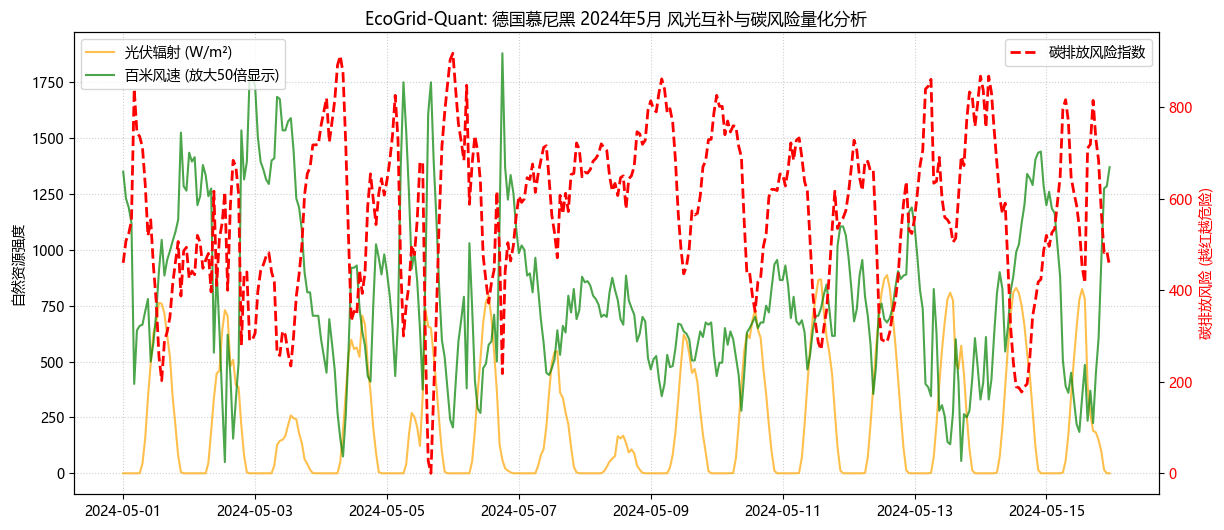

In [8]:
# 1. 召唤画图神器 Matplotlib 的核心模块
import matplotlib.pyplot as plt

# 2. 【强迫症专属防雷系统】强制开启中文支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 3. 【核心运筹逻辑】计算极其粗略的“电网碳排放风险指数”
# 逻辑：如果光伏辐射低，且风速也低，我们就认为此时只能依赖火电，碳排风险极高！
# 注意：这只是一个教学演示模型，真实的电网运筹模型比这个复杂一万倍。
df_munich["碳排放风险指数"] = (
    1000
    - (df_munich["光伏辐射_W/m2"] * 0.5)
    - (df_munich["百米风速_m/s"] * 20)
)
# 防御性编程：指数不能低于 0 (最少也是零碳)
df_munich.loc[df_munich["碳排放风险指数"] < 0, "碳排放风险指数"] = 0

# 4. 创建一个高级的“双轴画板” (因为风/光的数据大小和碳指数差异太大，不能放在同一个Y轴)
fig, ax1 = plt.subplots(figsize=(14, 6)) # 加长画板

# 5. 在左边的 Y 轴 (ax1) 画出大自然的恩赐：光伏和风力
ax1.plot(
    df_munich.index, df_munich["光伏辐射_W/m2"],
    color="orange", alpha=0.7, label="光伏辐射 (W/m²)",
)
ax1.plot(
    df_munich.index, df_munich["百米风速_m/s"] * 50,
    color="green", alpha=0.7, label="百米风速 (放大50倍显示)",
)
ax1.set_ylabel("自然资源强度", color="black")
ax1.tick_params(axis='y', labelcolor="black")
ax1.legend(loc="upper left") # 图例放在左上角

# 6. 生成一个共用 X 轴，但 Y 轴在右边的新图层 (ax2)
ax2 = ax1.twinx()

# 7. 在右边的 Y 轴 (ax2) 画出我们计算的【碳风险指数】
# 我们用极其显眼的红色虚线来表示危险！
ax2.plot(
    df_munich.index, df_munich["碳排放风险指数"],
    color="red", linestyle="--", linewidth=2, label="碳排放风险指数",
)
ax2.set_ylabel("碳排放风险 (越红越危险)", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax2.legend(loc="upper right") # 图例放在右上角

# 8. 加上标题和网格
plt.title("EcoGrid-Quant: 德国慕尼黑 2024年5月 风光互补与碳风险量化分析")
ax1.grid(True, linestyle=":", alpha=0.6)

# 9. 展现图表！
plt.show()


In [9]:
# 从你刚刚新建的 core 文件夹里，把你自己写的引擎“导入”进来！
from core.dispatch_engine import EcoGridOptimizer

# 实例化这个引擎 (相当于启动工厂流水线)
my_engine = EcoGridOptimizer(carbon_tax_rate=80.0)

# 测试引擎状态
my_engine.check_engine_status()

⚙️ EcoGrid 优化引擎已初始化！当前碳税设定: 80.0 €/t


AttributeError: 'EcoGridOptimizer' object has no attribute 'check_engine_status'

In [ ]:
# 1. 重新导入我们刚刚升级过大脑的引擎
from core.dispatch_engine import EcoGridOptimizer

# 2. 设定一个极高的欧洲标准碳税：80欧元/吨
engine = EcoGridOptimizer(carbon_tax_rate=80.0)

# 3. 设定物理场景：城市要 100 MW。但老天爷今天只给 30MW 风，20MW 光。
print("\n🔍 正在计算最优调度方案...")
optimal_result = engine.optimize_dispatch(demand=100.0, wind_avail=30.0, solar_avail=20.0)

# 4. 提取并打印出科学求解器给出的答案
print("-" * 30)
print(f"✅ 求解状态: {optimal_result.message}")
print(f"最优风电出力: {optimal_result.x[0]:.2f} MW")
print(f"最优光伏出力: {optimal_result.x[1]:.2f} MW")
print(f"被迫火电出力: {optimal_result.x[2]:.2f} MW")
print(f"最低综合成本: {optimal_result.fun:.2f} 欧元")

In [ ]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm  # 引入极客进度条

from core.dispatch_engine import EcoGridOptimizer

print("🚀 启动 EcoGrid 历史时间序列回测流水线...")

# 1. 初始化两台配置不同的引擎，做极具商业价值的【对照实验】
# 场景 A：无视环境，唯利是图 (碳税 = 0)
engine_dirty = EcoGridOptimizer(carbon_tax_rate=0.0)
# 场景 B：严苛的欧洲 ESG 标准 (碳税 = 80欧元/吨)
engine_green = EcoGridOptimizer(carbon_tax_rate=80.0)

# 设定微电网装机容量 (假设：风电场最大 50MW，光伏场最大 50MW)
WIND_CAPACITY = 50.0
SOLAR_CAPACITY = 50.0
DEMAND_MW = 100.0  # 假设城市每小时恒定需要 100 MW

# 准备一个空列表，用来装这 360 个小时的每一笔运筹结果
results_log = []

# 2. 核心战役：让引擎穿越时间，重演过去 15 天的每一次电网调度！
# (tqdm 会在下方渲染一个极漂亮的进度条)
for timestamp, row in tqdm(df_munich.iterrows(), total=len(df_munich), desc="⏳ 引擎日夜演算中"):

    # 【物理仿真】：把风速和太阳辐射，转化为能够上网的电量
    # 粗略物理模型：风速 * 3，最多不超过装机容量；辐射 * 0.05，最多不超过装机容量
    current_wind_mw = min(max(row["百米风速_m/s"] * 3.0, 0), WIND_CAPACITY)
    current_solar_mw = min(max(row["光伏辐射_W/m2"] * 0.05, 0), SOLAR_CAPACITY)

    # 让环保引擎进行求解
    res_green = engine_green.optimize_dispatch(DEMAND_MW, current_wind_mw, current_solar_mw)

    # 记录这一个小时发生的一切
    results_log.append({
        "时间": timestamp,
        "理论可用风电_MW": current_wind_mw,
        "理论可用光伏_MW": current_solar_mw,
        "绿色组_火电出力_MW": res_green.x[2],
        "绿色组_总成本_欧": res_green.fun,
        "绿色组_碳排_吨": res_green.x[2] * 0.9
    })

# 3. 把几百条战斗日志，瞬间压缩成顶级 DataFrame 数据库！
df_backtest = pd.DataFrame(results_log).set_index("时间")

print("✅ 回测完成！截取极端天气下的 5 个小时进行审查：")
# 我们故意挑出几行数据，让招生官看看你的引擎是怎么工作的
df_backtest.sample(5).sort_index()

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# 1. 强迫症防雷：开启中文与高清显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 创建一个“上下两层”的联合画板，并让它们共用同一个时间 X 轴
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ==========================================
# 【上层：物理调度层】展现风光互补与火电“填谷”
# ==========================================
# 我们用灰色的“实心面积图”来表示被迫烧煤的量，给人强烈的压迫感
ax1.fill_between(df_backtest.index, 0, df_backtest["绿色组_火电出力_MW"],
                 color='gray', alpha=0.4, label='系统脆弱期：被迫启用的火电 (高碳排)')

# 画出绿色的风和橙色的光
ax1.plot(
    df_backtest.index, df_backtest["理论可用风电_MW"],
    color='green', label='风电出力', linewidth=2,
)
ax1.plot(
    df_backtest.index, df_backtest["理论可用光伏_MW"],
    color='orange', label='光伏出力', linewidth=2,
)

ax1.set_ylabel('电网功率 (MW)', fontsize=12, fontweight='bold')
ax1.set_title(
    'EcoGrid-Quant 仿真报告：慕尼黑微电网 15天连续调度回测',
    fontsize=16, fontweight='bold',
)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# 【下层：金融与 ESG 风险层】展现碳税带来的成本暴击
# ==========================================
ax2.plot(df_backtest.index, df_backtest["绿色组_总成本_欧"],
         color='red', linewidth=2, label='系统总运行成本 (€) - 包含 80欧/吨 碳税')

ax2.set_ylabel('综合成本 (欧元/小时)', fontsize=12, fontweight='bold', color='red')
ax2.set_xlabel('回测时间 (2024年5月)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# 让底部的日期显示得更干净 (只显示 月-日)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# 3. 自动收紧排版，完美出图！
plt.tight_layout()
plt.show()


In [ ]:
from core.dispatch_engine import EcoGridOptimizer

# 1. 实例化你注入了 BESS (电池) 物理参数的新引擎
engine = EcoGridOptimizer(carbon_tax_rate=50.0)

# 2. 伪造一个微型的 24 小时 (horizon=24) 测试数据
horizon = 24
demand_mock = np.full(horizon, 50.0)      # 全天恒定需求 50MW
solar_mock = np.zeros(horizon)
solar_mock[10:15] = 80.0                  # 中午光伏极度过剩
wind_mock = np.full(horizon, 10.0)        # 风电全天平稳 10MW

# 3. 呼叫 SciPy 运筹求解器！
result = engine.optimize_horizon(demand_mock, wind_mock, solar_mock, horizon=horizon)

print(result.message)
print(f"跨期总成本极小值: {result.fun}")

⚙️ EcoGrid 优化引擎已初始化！当前碳税设定: 50.0 €/t
Optimization terminated successfully
跨期总成本极小值: 46550.000001689456


In [ ]:
import pandas as pd

# 1. 提取 SciPy 算出的最优解 (144个元素的数组)
optimal_x = result.x

# 2. 将扁平数组重塑 (Reshape) 为 24行(小时) x 6列(决策变量) 的矩阵
reshaped_x = optimal_x.reshape(horizon, 6)

# 3. 转化为专业的 Pandas 数据框
columns = ['Coal (MW)', 'Wind (MW)', 'Solar (MW)', 'Charge (MW)', 'Discharge (MW)', 'SoC (MWh)']
df_result = pd.DataFrame(reshaped_x, columns=columns)

# 为了方便阅读，把极小的浮点数误差(比如 1e-10)抹零，保留两位小数
df_result = df_result.round(2)

# 4. 终极验证：打印两个关键时间窗口，观察电池行为
print("☀️ 场景一：中午光伏暴发，碳排为0 (10:00 - 15:00)")
print("期待行为：电池应该在疯狂充电 (Charge > 0)，SoC 上升。")
print(df_result.iloc[10:16])
print("-" * 60)

print("🌙 场景二：晚间无光，火电狂烧，碳税爆表 (18:00 - 23:00)")
print("期待行为：电池应该在放电 (Discharge > 0) 替代火电，SoC 下降。")
print(df_result.iloc[18:24])

☀️ 场景一：中午光伏暴发，碳排为0 (10:00 - 15:00)
期待行为：电池应该在疯狂充电 (Charge > 0)，SoC 上升。
    Coal (MW)  Wind (MW)  Solar (MW)  Charge (MW)  Discharge (MW)  SoC (MWh)
10        0.0      10.00       52.35        12.35             0.0      11.73
11        0.0      10.00       57.92        17.92             0.0      28.75
12        0.0      10.00       65.00        25.00             0.0      52.50
13        0.0       4.24       70.76        25.00             0.0      76.25
14        0.0       0.00       75.00        25.00             0.0     100.00
15       15.0      10.00        0.00         0.00            25.0      73.68
------------------------------------------------------------
🌙 场景二：晚间无光，火电狂烧，碳税爆表 (18:00 - 23:00)
期待行为：电池应该在放电 (Discharge > 0) 替代火电，SoC 下降。
    Coal (MW)  Wind (MW)  Solar (MW)  Charge (MW)  Discharge (MW)  SoC (MWh)
18      28.76       10.0         0.0          0.0           11.24      11.03
19      34.57       10.0         0.0          0.0            5.43       5.32
20      37.36      

🚀 [EcoGrid-Quant V2] 正在构建多期 NLP 矩阵并求解，请稍候...
⚙️ EcoGrid 优化引擎已初始化！当前碳税设定: 80.0 €/t
✅ 求解成功！3天总调度成本极小值: € 442,758.80


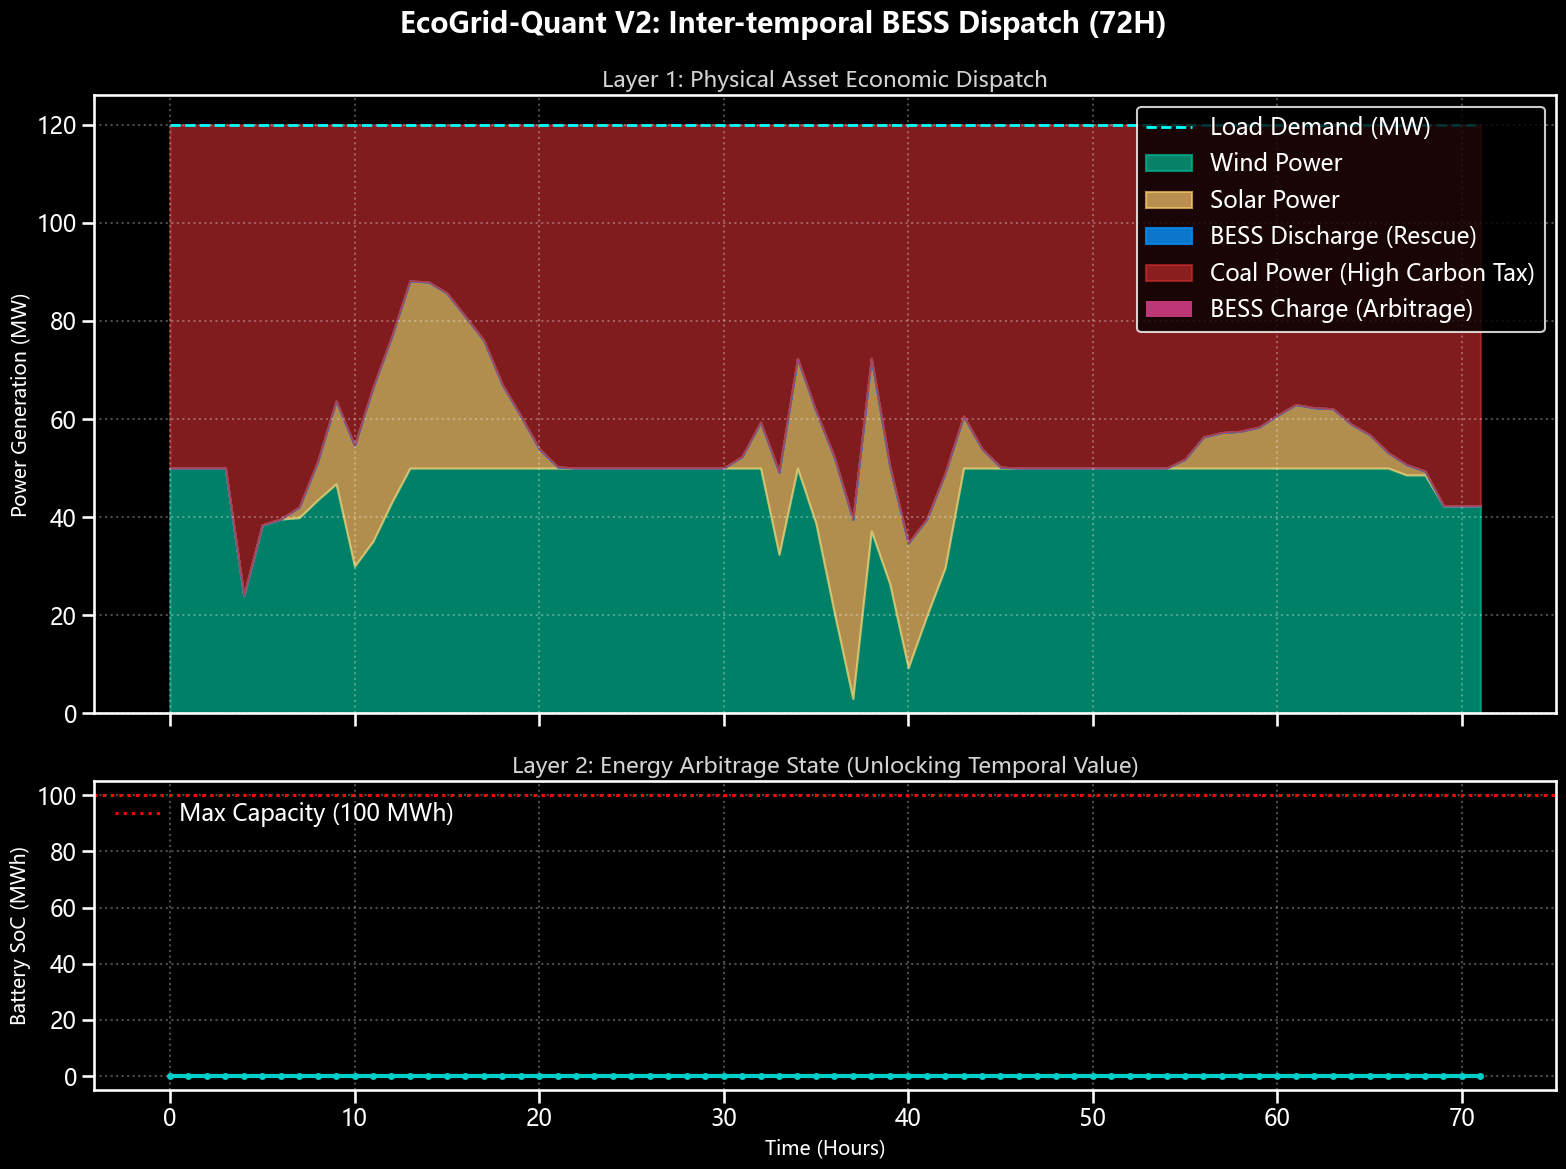

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from core.dispatch_engine import EcoGridOptimizer

# 设置全局极客画图风格
plt.style.use('dark_background')  # 完美契合 Cursor 和极客审美
sns.set_context("talk")

# ==========================================
# 1. 数据准备 (Data Ingestion) —— 接入 V1 真实慕尼黑数据
# ==========================================
horizon = 72  # 回测窗口：连续 3 天 (72小时)
demand_real = np.full(horizon, 120.0)  # 假设微电网有 120MW 的基础工业负荷

# 【真实数据接入】从 V1 抓取的 df_munich 中切取连续 72 小时
# 复用 V1 (Cell 8) 的物理仿真换算：风速*3、辐射*0.05，并限制在装机容量内
WIND_CAPACITY = 50.0    # 风电场最大装机 (MW)
SOLAR_CAPACITY = 50.0   # 光伏场最大装机 (MW)

df_window = df_munich.iloc[:horizon]  # 取真实数据的前 72 小时窗口

wind_real = np.clip(df_window["百米风速_m/s"].values * 3.0, 0, WIND_CAPACITY)
solar_real = np.clip(df_window["光伏辐射_W/m2"].values * 0.05, 0, SOLAR_CAPACITY)

# ==========================================
# 2. 点火！运行 V2 跨期动态运筹引擎
# ==========================================
print("🚀 [EcoGrid-Quant V2] 正在构建多期 NLP 矩阵并求解，请稍候...")
engine = EcoGridOptimizer(carbon_tax_rate=80.0)  # 调高碳税到 €80/吨，加大套利压力
result = engine.optimize_horizon(demand_real, wind_real, solar_real, horizon=horizon)

if result.success:
    print(f"✅ 求解成功！3天总调度成本极小值: € {result.fun:,.2f}")
else:
    print(f"❌ 求解失败: {result.message}")

# 提取并重塑矩阵结果
reshaped_x = result.x.reshape(horizon, 6)
df_res = pd.DataFrame(reshaped_x, columns=['Coal', 'Wind', 'Solar', 'Charge', 'Discharge', 'SoC'])
df_res['Demand'] = demand_real

# ==========================================
# 3. 研报级双层可视化 (Dual-Layer Attribution Chart)
# ==========================================
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]}, sharex=True,
)
fig.suptitle(
    'EcoGrid-Quant V2: Inter-temporal BESS Dispatch (72H)',
    fontsize=20, fontweight='bold', color='white',
)

# --- Top Layer: 物理资产调度流 (Asset Dispatch) ---
# 绘制需求基准线
ax1.plot(
    df_res.index, df_res['Demand'],
    color='cyan', linestyle='--', linewidth=2, label='Load Demand (MW)',
)

# 绘制零碳供能堆叠图 (风电 + 光伏 + 电池放电)
ax1.fill_between(df_res.index, 0, df_res['Wind'], color='#00b894', alpha=0.7, label='Wind Power')
ax1.fill_between(
    df_res.index, df_res['Wind'], df_res['Wind'] + df_res['Solar'],
    color='#fdcb6e', alpha=0.7, label='Solar Power',
)
renewable = df_res['Wind'] + df_res['Solar']
ax1.fill_between(
    df_res.index, renewable, renewable + df_res['Discharge'],
    color='#0984e3', alpha=0.9, label='BESS Discharge (Rescue)',
)

# 绘制高昂的碳排火电 (位于最顶层兜底)
base_clean = renewable + df_res['Discharge']
ax1.fill_between(
    df_res.index, base_clean, base_clean + df_res['Coal'],
    color='#d63031', alpha=0.6, label='Coal Power (High Carbon Tax)',
)

# 绘制充电行为 (由于吸收电网电量，画在负轴)
ax1.bar(
    df_res.index, -df_res['Charge'],
    color='#e84393', width=1.0, alpha=0.8, label='BESS Charge (Arbitrage)',
)

ax1.set_ylabel('Power Generation (MW)', fontsize=14, color='white')
ax1.legend(loc='upper right', frameon=True, facecolor='black', edgecolor='white')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.set_title('Layer 1: Physical Asset Economic Dispatch', color='lightgrey', fontsize=16)

# --- Bottom Layer: 金融运筹状态 (State of Charge) ---
ax2.plot(df_res.index, df_res['SoC'], color='#00cec9', linewidth=3, marker='o', markersize=4)
ax2.fill_between(df_res.index, 0, df_res['SoC'], color='#00cec9', alpha=0.2)
ax2.axhline(y=100.0, color='red', linestyle=':', label='Max Capacity (100 MWh)')

ax2.set_xlabel('Time (Hours)', fontsize=14, color='white')
ax2.set_ylabel('Battery SoC (MWh)', fontsize=14, color='white')
ax2.legend(loc='upper left', frameon=False)
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.set_title(
    'Layer 2: Energy Arbitrage State (Unlocking Temporal Value)',
    color='lightgrey', fontsize=16,
)

plt.tight_layout()
plt.show()
